In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from utils import (
    paut_size_from_torch,
    regularity_check,
    aut_grp_size_from_torch,
    evaluate_checkpoint,
)

sns.set_theme()

In [42]:
training_history_df = pd.read_csv(
    "results/baseline/larger_dataset/best_model_history.csv"
)

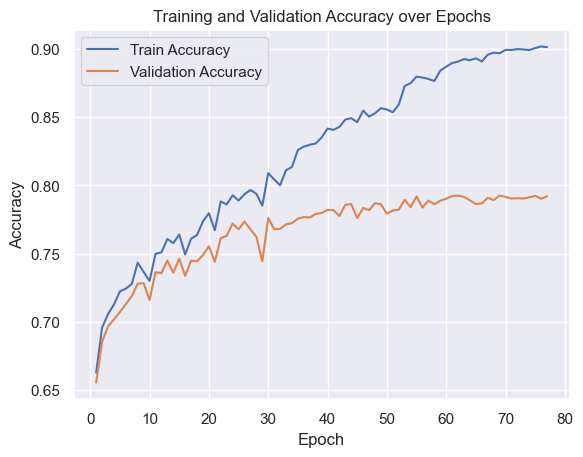

In [43]:
sns.lineplot(data=training_history_df, x="epoch", y="train_acc", label="Train Accuracy")
sns.lineplot(
    data=training_history_df, x="epoch", y="val_acc", label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy over Epochs")
plt.legend()
plt.show()

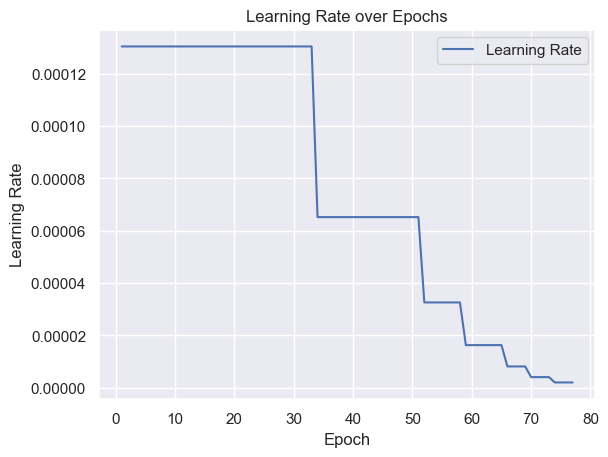

In [44]:
sns.lineplot(data=training_history_df, x="epoch", y="lr", label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate over Epochs")
plt.legend()
plt.show()

In [45]:
baseline_smaller_results = evaluate_checkpoint(
    config_path="results/baseline/best_config.json",
    dataset_path="dataset/test_dataset.pt",
    checkpoint_path="results/baseline/smaller_dataset/best_model.pt",
)

seven_features_results = evaluate_checkpoint(
    config_path="results/7_features/best_config_7_features.json",
    dataset_path="dataset/7_features/test_dataset_7_features.pt",
    checkpoint_path="results/7_features/best_model.pt",
)

baseline_larger_results = evaluate_checkpoint(
    config_path="results/baseline/best_config.json",
    dataset_path="dataset/test_dataset.pt",
    checkpoint_path="results/baseline/larger_dataset/best_model.pt",
)

In [55]:
model_results = {
    "Baseline Smaller": baseline_smaller_results,
    "Seven Features": seven_features_results,
    "Baseline Larger": baseline_larger_results,
}

model_comparison_df = pd.DataFrame(
    [
        {
            "Run": run_name,
            "Accuracy": run_results["accuracy"],
            "F1": run_results["f1"],
            "Examples": len(run_results["predictions_df"]),
        }
        for run_name, run_results in model_results.items()
    ]
)

selected_run_name = "Baseline Larger"
selected_results = model_results[selected_run_name]
selected_model = selected_results["model"]
selected_dataset = selected_results["dataset"]
selected_loader = selected_results["loader"]
predictions_df = selected_results["predictions_df"].copy()
model_comparison_df

,Run,Accuracy,F1,Examples
0,Baseline Smaller,0.762979,0.788537,6164
1,Seven Features,0.769468,0.789200,6164
2,Baseline Larger,0.780337,0.802854,6164


In [56]:
avg_group_size_all = (
    predictions_df.groupby("num_nodes")["aut_grp_size"].mean().reset_index()
)

wrong_predictions_df = predictions_df[~predictions_df["correct"]]
avg_group_size_wrong = (
    wrong_predictions_df.groupby("num_nodes")["aut_grp_size"].mean().reset_index()
)

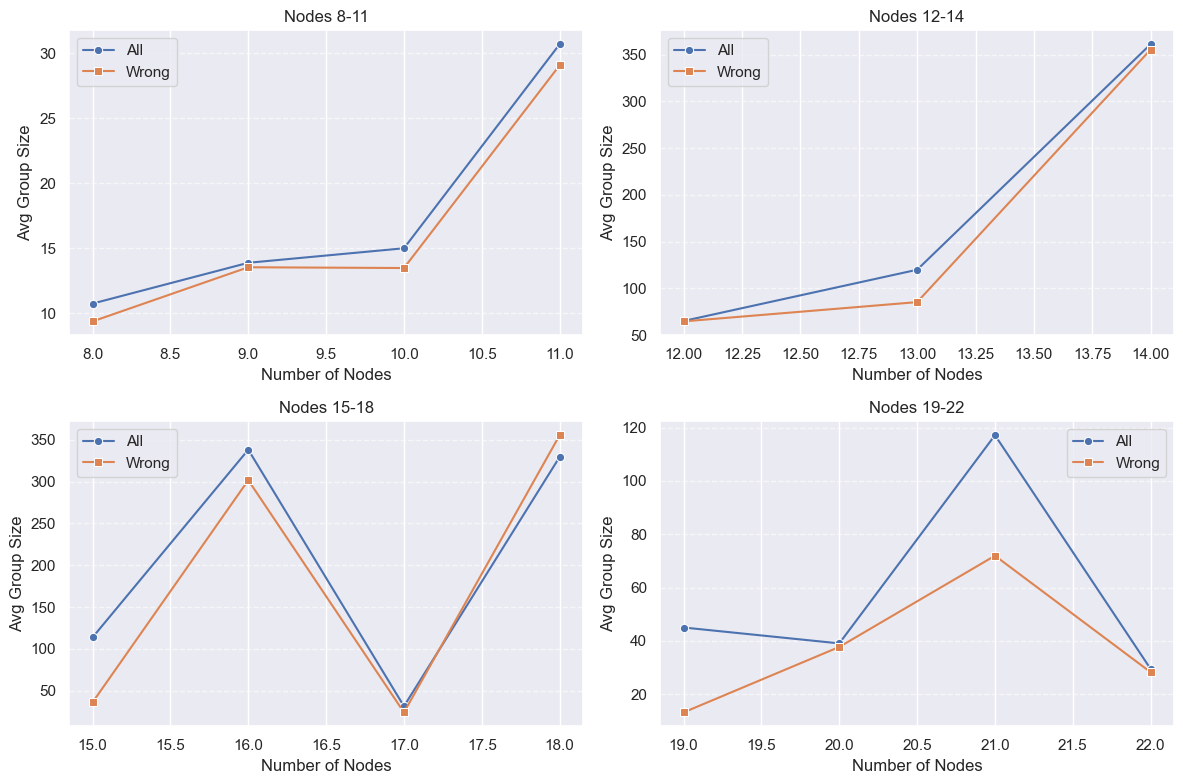

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ranges = [(8, 11), (12, 14), (15, 18), (19, 22)]
axes = axes.flatten()

for ax, (low, high) in zip(axes, ranges):
    mask_all = (avg_group_size_all["num_nodes"] >= low) & (
        avg_group_size_all["num_nodes"] <= high
    )

    mask_wrong = (avg_group_size_wrong["num_nodes"] >= low) & (
        avg_group_size_wrong["num_nodes"] <= high
    )

    sns.lineplot(
        data=avg_group_size_all[mask_all],
        x="num_nodes",
        y="aut_grp_size",
        marker="o",
        label="All",
        ax=ax,
    )

    sns.lineplot(
        data=avg_group_size_wrong[mask_wrong],
        x="num_nodes",
        y="aut_grp_size",
        marker="s",
        label="Wrong",
        ax=ax,
    )

    ax.set_title(f"Nodes {low}-{high}")
    ax.set_xlabel("Number of Nodes")
    ax.set_ylabel("Avg Group Size")
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()

In [59]:
@torch.no_grad()
def analyze_difficult_cases(
    model,
    loader,
    low_conf: float = 0.3,
    high_conf: float = 0.7,
    confident_wrong_cutoff: float = 0.2,
) -> pd.DataFrame:
    model.eval()
    difficult_cases = []
    sample_idx = 0

    for batch in loader:
        logits = model(batch).view(-1)
        probs = torch.sigmoid(logits)
        pred = (logits > 0).float()

        for i, graph in enumerate(batch.to_data_list()):
            prob = float(probs[i].item())
            true_label = int(graph.y.item())
            pred_label = int(pred[i].item())

            is_wrong = pred_label != true_label
            is_uncertain = low_conf < prob < high_conf
            is_confident_wrong = is_wrong and (
                prob < confident_wrong_cutoff or prob > 1 - confident_wrong_cutoff
            )

            if is_wrong or is_uncertain or is_confident_wrong:
                difficult_cases.append(
                    {
                        "sample_idx": sample_idx,
                        "num_nodes": graph.num_nodes,
                        "paut_size": paut_size_from_torch(graph),
                        "aut_grp_size": aut_grp_size_from_torch(graph),
                        "regular": regularity_check(graph),
                        "pred_prob": prob,
                        "pred_label": pred_label,
                        "true_label": true_label,
                        "type": (
                            "confident_wrong"
                            if is_confident_wrong
                            else "wrong"
                            if is_wrong
                            else "uncertain"
                        ),
                    }
                )

            sample_idx += 1

    return pd.DataFrame(difficult_cases)


difficult_cases_df = analyze_difficult_cases(selected_model, selected_loader)
print(f"Active run: {selected_run_name}")
print(f"Difficult cases: {len(difficult_cases_df)} / {len(selected_dataset)}")
difficult_cases_df.head()

Active run: Baseline Larger
Difficult cases: 2100 / 6164


,sample_idx,num_nodes,paut_size,aut_grp_size,regular,pred_prob,pred_label,true_label,type
0,1,10,7,4.0,False,0.404892,0,1,wrong
1,2,10,6,4.0,False,0.362355,0,1,wrong
2,3,10,6,4.0,False,0.565037,1,1,uncertain
3,5,10,7,4.0,False,0.889955,1,0,confident_wrong
4,7,10,6,4.0,False,0.458484,0,0,uncertain


Key Questions to Answer:

- Are small or large graphs harder?
- Are graphs with larger partial mappings harder?
- Are false positives or false negatives more common?

  - False positives: Model says extendable but it's not
  - False negatives: Model says not extendable but it is


Do difficult cases have specific structural patterns? (e.g., high symmetry, specific density)

Benefits:

✅ Understand model limitations: What structures confuse it?

✅ Guide improvements: Should you add more features? More layers? Different architecture?

✅ Data augmentation: Generate more training examples similar to hard cases

✅ Model debugging: Visualize hard graphs to understand failure modes

✅ Research insights: Discover interesting graph properties related to automorphism extension